# Analytic calculations

## Packages

In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True,
                 "text.usetex": True,
                 "font.family": "Computer Modern Roman"})


## Plotting font options ##
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import numpy as np
import scipy

from pathlib import PosixPath
user_home_path = PosixPath('~/')
user_home_path_full = user_home_path.expanduser()

import sys
sys.path.append("../")

import autolib
import dynplot
import Optimisation.opt as opt
import parameters
I_par, L, m, c = parameters.Parameters()

## Linear dynamics without damping

Numerical eigenvalues: [ 0.45508986+1.09868411j -0.45508986+1.09868411j  0.45508986-1.09868411j
 -0.45508986-1.09868411j]
Analytic eigenvalues : [ 0.45508986-1.09868411j -0.45508986+1.09868411j  0.45508986+1.09868411j
 -0.45508986-1.09868411j]


/opt/miniconda3/envs/py12/lib/python3.12/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


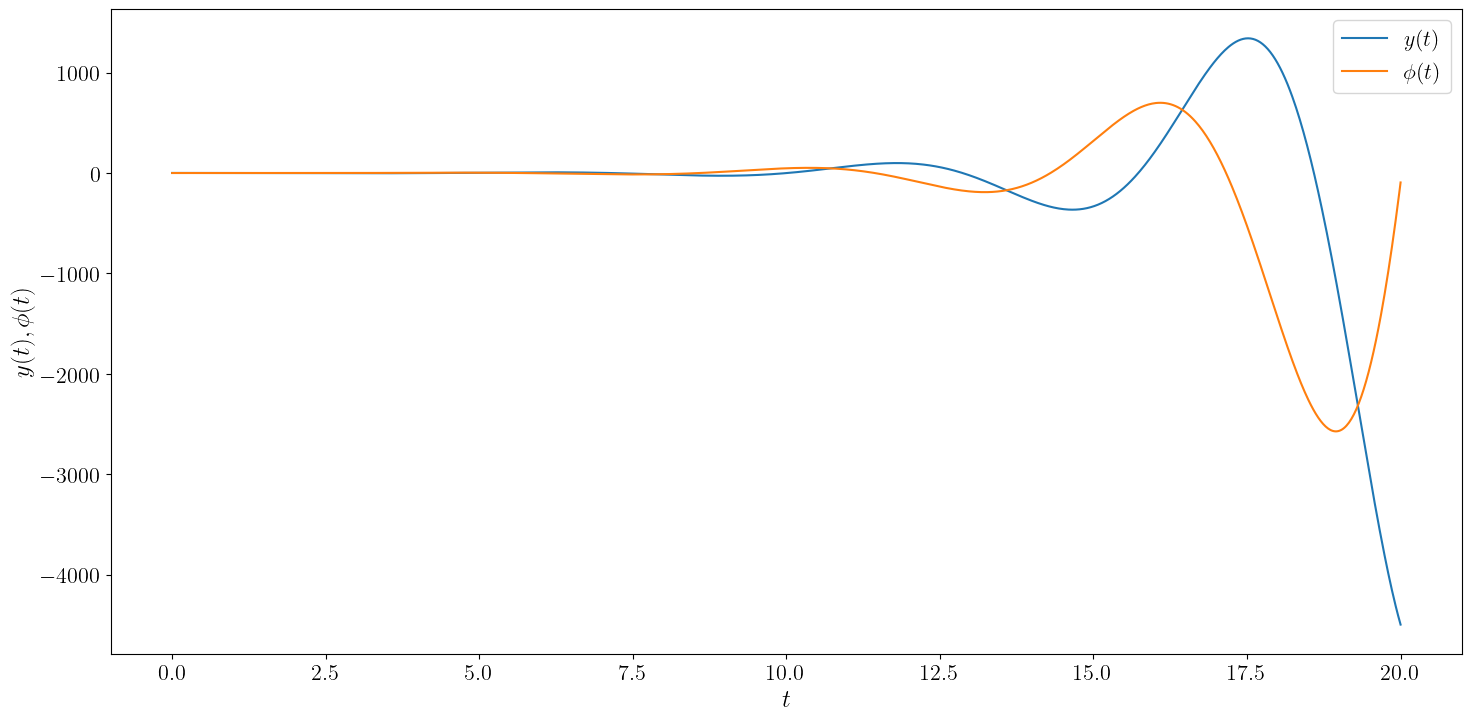

In [15]:
kyy = -1. + 0.j
kyp = 1. + 0.j
kpy = -1. + 0.j
kpp = -1. + 0.j

jacobian = np.array([[0., 0., 1., 0.], 
                     [0., 0., 0., 1.], 
                     [kyy, kyp, 0., 0.], 
                     [kpy, kpp, 0., 0.]])

# Evaluate eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(jacobian)
analytic_eigenvalue12 = 1/np.sqrt(2) * np.sqrt(kyy + kpp - np.sqrt((kyy - kpp)**2 + 4*kyp*kpy))
analytic_eigenvalue34 = 1/np.sqrt(2) * np.sqrt(kyy + kpp + np.sqrt((kyy - kpp)**2 + 4*kyp*kpy))
analytic_eigenvalues = np.array([analytic_eigenvalue12, -analytic_eigenvalue12, analytic_eigenvalue34, -analytic_eigenvalue34])
print("Numerical eigenvalues:", eigenvalues)
print("Analytic eigenvalues :", analytic_eigenvalues)

# Solve ODEs
def dydt(t, y):
    return jacobian @ y

t_eval = np.linspace(0, 20, 1000)
y0 = np.array([1., 0., 0., 0.])
sol = scipy.integrate.solve_ivp(dydt, (t_eval[0], t_eval[-1]), y0, t_eval=t_eval)

fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[0], label=r'$y(t)$')
ax.plot(sol.t, sol.y[1], label=r'$\phi(t)$')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$y(t), \phi(t)$')
ax.legend()
plt.show()

## Jacobian Terms width-dependence

In [ ]:
num_points = 500
bounds = (0.01, 2.)  # Width bounds in units of L
ws = np.linspace(*bounds, num_points)
rt2 = np.sqrt(2)
rt2pi = np.sqrt(2/np.pi)
expw = np.exp(-1/(2*ws**2))
erfw = scipy.special.erf(1/(ws*rt2))

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# Width-dependence with fixed peak-intensity
y1 = rt2pi * (1 - expw)
y2 = ws/2 * erfw
y3 = ws**2/4 * y1
y4 = y2 - rt2pi/2*expw
y5 = ws**2/4 * y4

fixed_peak_ws = [y1, y2, y3, y4, y5]
fixed_power_ws = [y/ws for y in fixed_peak_ws]

fixed_peak_labels = [r"$y_1 = \sqrt{\frac{2}{\pi}} \left(1 - e^{-\frac{1}{2w^2}}\right)$",
                     r"$y_2 = \frac{w}{2} \operatorname{erf}\left(\frac{1}{\sqrt{2}w}\right)$",
                     r"$y_3 = \frac{w^2}{4} y_1$",
                     r"$y_4 = y_2 - \frac{1}{2} \sqrt{\frac{2}{\pi}} e^{-\frac{1}{2w^2}}$",
                     r"$y_5 = \frac{w^2}{4} y_4$"]
fixed_power_labels = [r"$w_\infty = \sqrt{\frac{2}{\pi}} \frac{1}{w} \left(1 - e^{-\frac{1}{2w^2}}\right)$",
                      r"$w_{1/2}^\text{slow} = \frac{1}{2} \operatorname{erf}\left(\frac{1}{\sqrt{2}w}\right)$",
                      r"$w_{0}^\text{slow} = \frac{w^2}{4} y_1$",
                      r"$w_{1/2}^\text{fast} = y_2 - \frac{1}{2w} \sqrt{\frac{2}{\pi}} e^{-\frac{1}{2w^2}}$",
                      r"$w_{0}^\text{fast} = \frac{w^2}{4} y_4$"]

# Plotting
figsize = (6,5)
fixed_peak_fig, fixed_peak_ax = plt.subplots(1, figsize=figsize)
fixed_power_fig, fixed_power_ax = plt.subplots(1, figsize=figsize)
for i in range(5):
    fixed_peak_ax.plot(ws, fixed_peak_ws[i], color=CB_color_cycle[i], linewidth=2.5, label=fixed_peak_labels[i])
    dynplot.show_standard_axes(fixed_peak_ax, None, xlabel=r"$w/L$", ylabel=r"Fixed-peak intensity $w$'s", show_zero_line=False)
    fixed_peak_ax.set(xlim=(ws[0], ws[-1]), ylim=(0., 1.05))

    fixed_power_ax.plot(ws, fixed_power_ws[i], color=CB_color_cycle[i], linewidth=2.5, label=fixed_power_labels[i])
    dynplot.show_standard_axes(fixed_power_ax, None, xlabel=r"$w/L$", ylabel=r"Fixed-power $w$'s", show_zero_line=False)
    fixed_power_ax.set(xlim=(ws[0], ws[-1]), ylim=(0., 1.05))

fixed_peak_fig.legend(loc='center left', frameon=False, bbox_to_anchor=(1., 0.55))
fixed_power_fig.legend(loc='center left', frameon=False, bbox_to_anchor=(1., 0.55))

# ftype = ".pdf"
# save_fname = fname_preamble + f"/Dynamics/{runID}_width_dependence_{i}" + ftype
# fig.savefig(save_fname, bbox_inches="tight")

## Doppler factor wavelength dependence

In [ ]:
import dynplot

final_speed = 20.
num_points = 200
betas = np.linspace(0,final_speed/100, num_points)
vels = [[b,0] for b in betas]
Dopplers = np.array(parameters.D1_ND(vels))
gammas = np.array(parameters.gamma_ND(vels))
Dsq = Dopplers**2
D_plus_1 = (Dopplers+1)/(Dopplers*(gammas+1))
fig, ax = plt.subplots(1, figsize=(6,5))
ax = dynplot.plot_array_on_same_axes(ax, betas, Dopplers, linewidth=2.5, color="red", linestyle="--", label=r"$D$")
ax = dynplot.plot_array_on_same_axes(ax, betas, Dsq, linewidth=2.5, color="blue", linestyle="-", label=r"$D^2$")
ax = dynplot.plot_array_on_same_axes(ax, betas, D_plus_1, linewidth=2.5, color="green", linestyle="-.", label=r"$(D+1)/[D(\gamma+1)]$")
ax = dynplot.show_standard_axes(ax, betas, xlabel=r"$\beta$", ylabel=r"Doppler factor", show_zero_line=False, ax_width=2.5)
fig.legend(loc='upper right')

print(np.average(Dsq))

## Grating pitch corresponding to a certain angle before first-order cutoff

In [ ]:
final_speed = 20.
angle_max = 0.01*np.pi/180
wavelength_max = 1/parameters.D1_ND([final_speed/100.,0.])

pitch_min = wavelength_max/(1 - np.sin(angle_max))
print(pitch_min)

## Maximising V-mirror damping

### Intercepted power from a Gaussian

In [2]:
L = 10  # Length of the grating, m
w = 20  # Half-width of the Gaussian beam, m
P0 = 50e9  # Total beam power, W
Pint = P0*scipy.special.erf(L/(np.sqrt(2)*w))
Iequiv = Pint/L  # Equivalent plane-wave intensity
print(f"Power intercepted: {Pint:.2E} GW")
print(f"Corresponding plane-wave intensity: {Iequiv:.2E} GW/m^2")

Power intercepted: 1.91E+10 GW
Corresponding plane-wave intensity: 1.91E+09 GW/m^2


### Graphical maximum

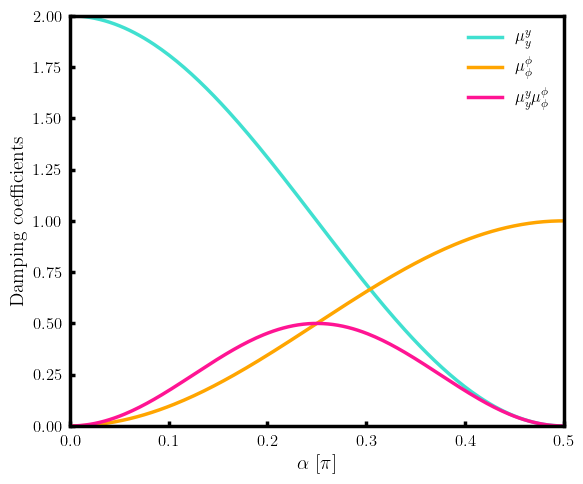

In [3]:
num_points = 200
alphas = np.pi/2*np.linspace(0.,1, num_points)
# # Fixing cross-sectional area and thickness
myy = np.cos(alphas)*np.sin(2*alphas)
mpp = np.sin(alphas)**3
# With fixed geometric cross-section
myy = 2*np.cos(alphas)**2
mpp = np.sin(alphas)**2
total_damp = myy*mpp

fig, ax = plt.subplots(1, figsize=(6,5))
ax.plot(alphas/np.pi, myy, color="turquoise", linewidth=2.5, label=r"$\mu^y_y$")
ax.plot(alphas/np.pi, mpp, color="orange", linewidth=2.5, label=r"$\mu^\phi_\phi$")
ax.plot(alphas/np.pi, total_damp, color="deeppink", linewidth=2.5, label=r"$\mu^y_y \mu^\phi_\phi$")
ax.set(xlim=(0.,0.5), ylim=(-0.,2.))
ax.tick_params(axis='both', pad=6)
dynplot.show_standard_axes(ax, None, xlabel=r"$\alpha$ [$\pi$]", ylabel=r"Damping coefficients", show_zero_line=False, ax_width=2.5)
ax.legend(frameon=False)

# fig.savefig("/Users/jlin0351/Downloads/damping_coefficients.pdf", bbox_inches="tight")

### Damping coefficients

Two reasonable options:
* Fix the intercepted beam power and total mass of VM, BG (thickness increases with increasing mirror angle)
* Fix the intercepted beam power and thickness of VM, BG (mass decreases with increasing mirror angle)
The former has a maximum damping product at mirror angle at $\pi/4$, whereas the latter has a maximum mirror angle around $0.3\pi$.

In [10]:
alpha0 = np.pi/4  # half-angle between mirrors that maximises the damping product
# alpha0 = 0.3*np.pi  # half-angle between mirrors that maximises the damping product
A0 = 5/np.sin(alpha0)  # mirror area, m
# A0 = 5  # mirror area, m
# D2 = 0.8  # Average Doppler factor
D2 = 1.  # Average Doppler factor
# I0 = 5e9  # Plane-wave intensity, W/m^2
I0 = Iequiv  # Plane-wave intensity, W/m^2
m = 1e-3  # Sail mass, kg
c = 3e8   # Speed of light, m/s

# areal_density = 1e-4  # kg/m^2
areal_density = m/A0  # kg/m^2

myy = -4*D2*I0/(areal_density*c**2)*np.cos(alpha0)*np.sin(2*alpha0)
mpp = -8*D2*I0/(areal_density*c**2)*np.sin(alpha0)**3

print(f"Damping coefficients:\nmyy = {myy:.2E} s^-1\nmpp = {mpp:.2E} s^-1")

Damping coefficients:
myy = -4.25E-04 s^-1
mpp = -4.25E-04 s^-1


## Solar-magnetic-field paddle OOM

In [ ]:
c = scipy.constants.c
mu0 = scipy.constants.mu_0
solar_flux = 1361  # At 1 AU, W/m^2
sail_area = 10  # m
sail_anguler_vel = 1e4  # rad/s
sail_length = 10  # m

solar_rotation_frequency = 1/(25.67*24*3600)  # 1/s
inner_radial_distance = 2e3/solar_rotation_frequency  # m, inner boundary around the Sun
radial_distance = 1.5e11  # m, distance from the Sun
solar_wind_speed = 400e3  # m/s, average solar wind speed
B0 = 1  # T, magnetic field strength at the inner boundary around the Sun
Bfield_gradient = inner_radial_distance**2*solar_rotation_frequency*B0/(solar_wind_speed * radial_distance**2)  # T/m

# Maximum charge before radiated power exceeds absorbed power
charge_max = np.sqrt(48*c**3*sail_area*solar_flux/(mu0*sail_length**4*sail_anguler_vel**6))

force_magnetic = 1/2 * charge_max * sail_length**2 * sail_anguler_vel * Bfield_gradient
force_radiation = 3*sail_area*solar_flux/c
relative_force = force_magnetic/force_radiation

print(f"Maximum charge: {charge_max:.2E} C")
print(f"Magnetic force: {force_magnetic:.2E} N")
print(f"Radiation force: {force_radiation:.2E} N")
print(f"Relative force: {relative_force:.2E}")